# Keras MNIST


* Atividade PEL219 - Keras MNIST - Gabriel Melo. Matrícula: 125.304-6

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib import pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

I0000 00:00:1773009789.690678   11411 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773009790.079668   11411 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773009791.297318   11411 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

In [3]:

y_train = to_categorical(y_train)

In [4]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000, 10), (10000, 28, 28), (10000,))

In [5]:
model = Sequential() 
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(1280, activation="sigmoid"))
model.add(Dense(640, activation="sigmoid"))
model.add(Dense(10, activation="softmax"))  # digit numbers
model.compile('adam', 'categorical_crossentropy', metrics=['categorical_accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1773009814.007289   11411 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5590 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1280)           │     1,004,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 640)            │       819,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         6,410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,831,050 (6.98 MB)

 Trainable params: 1,831,050 (6.98 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(x=x_train, y=y_train, epochs=10, validation_split=.1)


Epoch 1/10


I0000 00:00:1773009830.509878   12215 service.cc:153] XLA service 0x7907dc032bf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773009830.509903   12215 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1773009830.532363   12215 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773009830.612353   12215 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1773009830.618105   12215 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1356__.17


  32/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - categorical_accuracy: 0.1576 - loss: 2.5898

I0000 00:00:1773009832.937024   12215 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1661/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.8112 - loss: 0.6065

I0000 00:00:1773009836.009457   12215 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1356__.17


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - categorical_accuracy: 0.8950 - loss: 0.3410 - val_categorical_accuracy: 0.9598 - val_loss: 0.1320
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - categorical_accuracy: 0.9582 - loss: 0.1374 - val_categorical_accuracy: 0.9698 - val_loss: 0.1003
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - categorical_accuracy: 0.9733 - loss: 0.0859 - val_categorical_accuracy: 0.9765 - val_loss: 0.0759
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - categorical_accuracy: 0.9813 - loss: 0.0598 - val_categorical_accuracy: 0.9797 - val_loss: 0.0725
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - categorical_accuracy: 0.9861 - loss: 0.0425 - val_categorical_accuracy: 0.9780 - val_loss: 0.0818
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - categorical_accuracy: 0.9901 - loss: 0.0306 - val_categorical_accuracy: 0.9813 - val_loss: 0.0691
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - categorical_accuracy: 0.9921 - 

## Testing

In [8]:
results = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [9]:
results_class = np.argmax(results, axis=1)

In [10]:
accuracy_score(results_class, y_test), precision_score(results_class, y_test, average="weighted"), recall_score(results_class, y_test, average="weighted"), f1_score(results_class, y_test, average="weighted")

(0.9814, 0.9814336024771592, 0.9814, 0.9813918794707784)

In [11]:
print(classification_report(y_test, results_class))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.97      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.99      0.98      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



<Axes: >

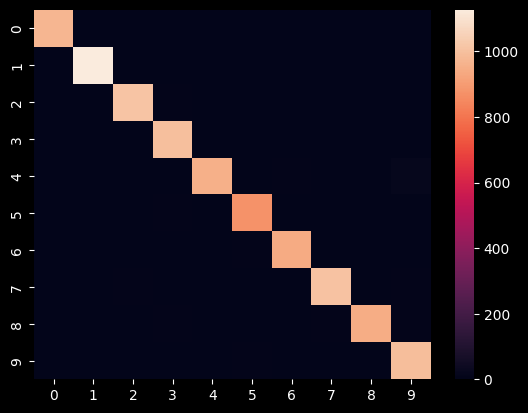

In [12]:
sns.heatmap(confusion_matrix(y_test, results_class))

## Training data

In [13]:
df = pd.DataFrame(history.history)

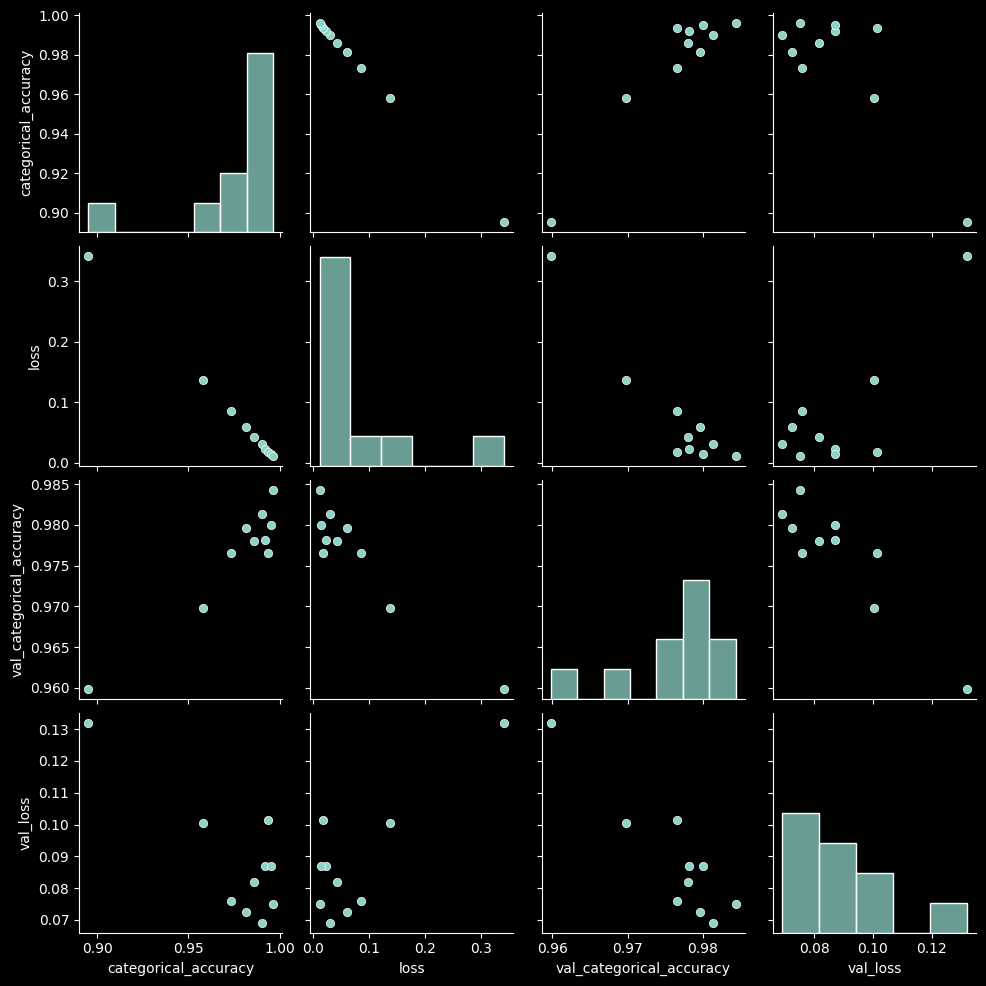

In [14]:
sns.pairplot(df)

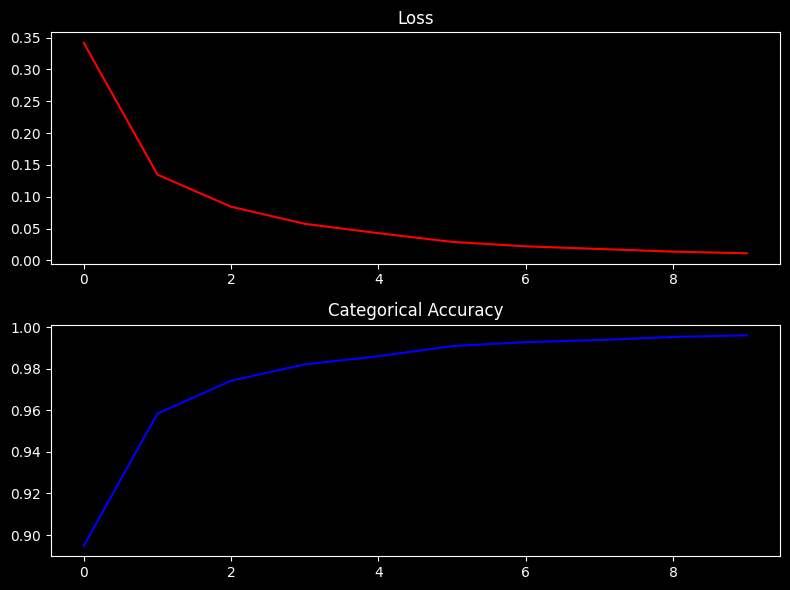

In [19]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 6))

ax[0].plot(df['loss'], color='red')
ax[0].set_title("Loss")

ax[1].plot(df['categorical_accuracy'], color='blue')
ax[1].set_title("Categorical Accuracy")

fig.tight_layout()